In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

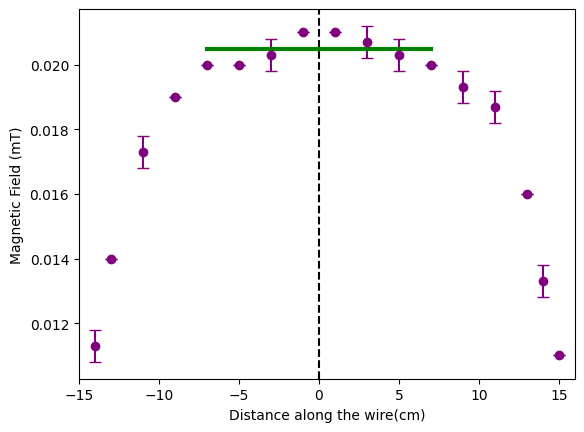

In [61]:
#Experiment 1 - A

x = np.array([-14, -13, -11, -9, -7, -5, -3, -1, 1, 3, 5, 7, 9, 11, 13, 14, 15])


data = [0.0113, 0.014, 0.0173, 0.019, 0.020, 0.020, 0.0203, 0.021, 0.021, 0.0207, 0.0203, 0.02, 0.0193, 0.0187, 0.016, 0.0133, 0.011]
stdev = [0.0005, 0, 0.0005, 0, 0, 0, 0.0005, 0, 0, 0.0005, 0.0005, 0, 0.0005, 0.0005, 0, 0.0005, 0]



fig, ax = plt.subplots()

ax.errorbar(x, data, yerr=stdev,
            fmt="o", color="purple", capsize=4,
           )
ax.set_xlim(-15, 16)
ax.axvline(0, color = "black", linestyle='--')  # vertical center line
ax.plot([-7, 7], [0.0205, 0.0205], color='green', linewidth=3)
ax.set_xlabel("Distance along the wire(cm)")
ax.set_ylabel("Magnetic Field (mT)")

plt.show()

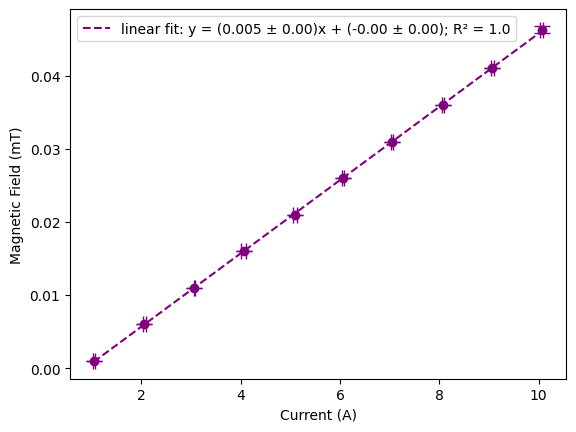

μ₀ values: [0.00018072 0.00054822 0.00067605 0.00074156 0.00077722 0.00080913
 0.00082885 0.00084119 0.00085236 0.00086753]
Average μ₀: 7.1228e-04
Standard deviation: 1.9979e-04
μ₀ from slope: 9.4500e-04 ± 2.4953e-06


In [63]:
#Experiment 1 - B

x = np.array([1.043, 2.063, 3.067, 4.067, 5.093, 6.057, 7.050, 8.067, 9.067, 10.06])
x_stdev = np.array([0.021, 0.029, 0.012, 0.049, 0.038, 0.017, 0.014, 0.019, 0.031, 0.036])

data = np.array([0.001, 0.006, 0.011, 0.016, 0.021, 0.026, 0.031, 0.036, 0.041, 0.0463])
data_stdev = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0.0005])

def lin(x,a,b):
    return a*x+b

def r_squared(y, yf, sigma):
    y_data = np.array(y)
    y_fit = np.array(yf)
    ss_res = np.sum((y_data - y_fit) ** 2)              
    ss_tot = np.sum((y_data - np.mean(y_data)) ** 2)   
    return 1 - (ss_res / ss_tot)

total_err = np.sqrt(x_stdev**2 + data_stdev**2)
po1, pc1 = curve_fit(lin, x, data, p0=[1, 0.002])
perr = np.sqrt(np.diag(pc1))
a_err, b_err = perr
a, b = po1

fig, ax = plt.subplots()
ax.plot(x,
        lin(x, *po1),
        linestyle="dashed",
        color="purple",
        label=f"linear fit: y = ({a:.3f} ± {a_err:.2f})x + ({b:.2f} ± {b_err:.2f}); R² = {np.round(r_squared(data, lin(x, *po1), total_err), 3)}")
ax.errorbar(x, data, xerr=x_stdev, yerr=data_stdev,
            fmt="o", color="purple", capsize=6,markersize = 6
           )
ax.set_xlabel("Current (A)")
ax.set_ylabel("Magnetic Field (mT)")
ax.legend()
plt.show()


r = 0.03  # radius in meters
mu0_from_slope = a * 2 * np.pi * r
mu0_err_from_slope = a_err * 2 * np.pi * r


mu0_array = np.array([(data[i] * 2 * np.pi* r) / x[i] for i in range(len(data))])
mu0_mean = np.mean(mu0_array)
mu0_stdev = np.std(mu0_array)

print(f"μ₀ values: {mu0_array}")
print(f"Average μ₀: {mu0_mean:.4e}")
print(f"Standard deviation: {mu0_stdev:.4e}")
print(f"μ₀ from slope: {mu0_from_slope:.4e} ± {mu0_err_from_slope:.4e}")

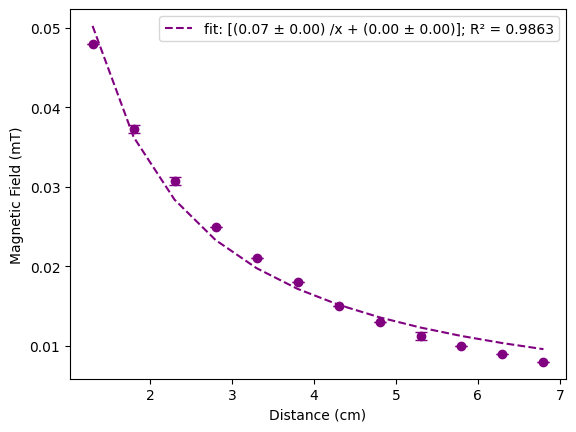

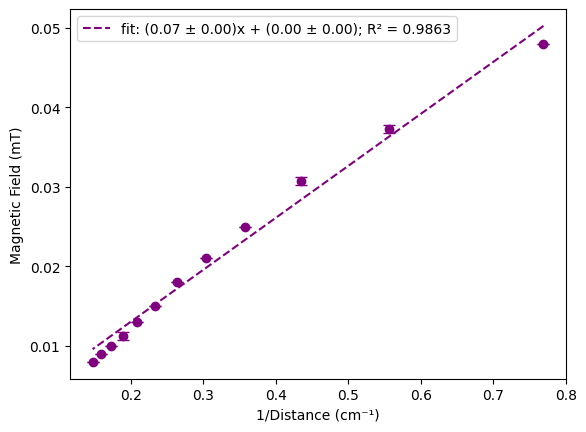

In [64]:
# Experiment 2 - C

r = np.array([1.3, 1.8, 2.3, 2.8, 3.3, 3.8, 4.3, 4.8, 5.3, 5.8, 6.3, 6.8])
B = np.array([0.048, 0.0373, 0.0307, 0.025, 0.021, 0.018, 0.015, 0.013, 0.0113, 0.01, 0.009, 0.008])
stdev_B = np.array([0, 0.0005, 0.0005, 0, 0, 0, 0, 0, 0.0005, 0, 0, 0])


def lin(x,a,b):
    return a*x+b

def inv(x,c,d):
    return c/x+d

def r_squared(y,yf):
    y_data = np.array(y)
    y_fit = np.array(yf)
    ss_res = np.sum((y_data - y_fit) ** 2)              
    ss_tot = np.sum((y_data - np.mean(y_data)) ** 2)   
    return 1 - (ss_res / ss_tot)

po1, pc1 = curve_fit(inv, r, B, p0=[1,0.002], bounds=(0, np.inf))

perr1 = np.sqrt(np.diag(pc1))
c_err, d_err = perr1
c, d = po1

fig, ax = plt.subplots()

ax.errorbar(r, B, yerr=stdev_B,
            fmt="o", color="purple", capsize=4,
           )
ax.plot(r,
        inv(r, *po1),
        linestyle="dashed",
        color="purple",
        label=f"fit: [({c:.2f} ± {c_err:.2f}) /x + ({d:.2f} ± {d_err:.2f})]; R² = {np.round(r_squared(B, inv(r, *po1)),4)}")
ax.set_xlabel("Distance (cm)")
ax.set_ylabel("Magnetic Field (mT)")
ax.legend()

plt.show()



r_inv = 1 / r
 
po2, pc2 = curve_fit(lin, r_inv, B, p0=[1,0.002], bounds=(0, np.inf))

perr2 = np.sqrt(np.diag(pc2))
a_err, b_err = perr2
a, b = po2 

fig, ax = plt.subplots()

ax.errorbar(r_inv, B, yerr=stdev_B,
            fmt="o", color="purple", capsize=4,
           )
ax.plot(r_inv,
        lin(r_inv, *po2),
        linestyle="dashed",
        color="purple",
        label=f"fit: ({a:.2f} ± {a_err:.2f})x + ({b:.2f} ± {b_err:.2f}); R² = {np.round(r_squared(B, lin(r_inv, *po2)),4)}")
ax.set_xlabel("1/Distance (cm⁻¹)")
ax.set_ylabel("Magnetic Field (mT)")
ax.legend()
plt.show()
plt.show()

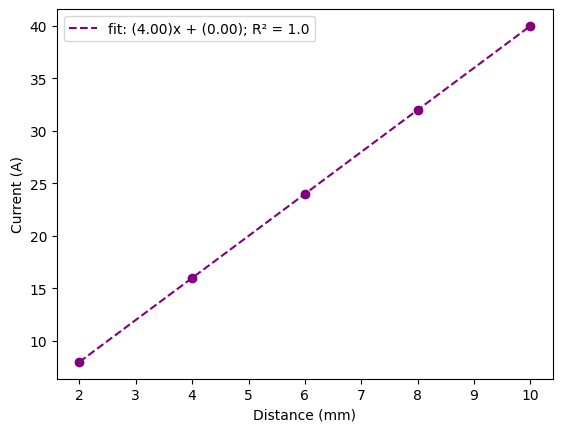

In [60]:
#Preparatory question 3

I = np.array([2,4,6,8,10])
r = np.array([8,16,24,32,40])

def lin (x,a,b):
    return a*x+b

def r_squared(y,yf):
    y_data = np.array(y)
    y_fit = np.array(yf)
    ss_res = np.sum((y_data - y_fit) ** 2)              
    ss_tot = np.sum((y_data - np.mean(y_data)) ** 2)   
    return 1 - (ss_res / ss_tot)

po2, pc2 = curve_fit(lin, I, r, p0=[1,0.002], bounds=(0, np.inf))



c, d = po2

fig, ax = plt.subplots()
ax.plot(I, r, "o", color="purple")
ax.plot(I,
        lin(I, *po2),
        linestyle="dashed",
        color="purple",
        label=f"fit: ({c:.2f})x + ({d:.2f}); R² = {np.round(r_squared(r, lin(I, *po2)),4)}")
ax.legend()
ax.set_xlabel("Distance (mm)")
ax.set_ylabel("Current (A)")


plt.show()


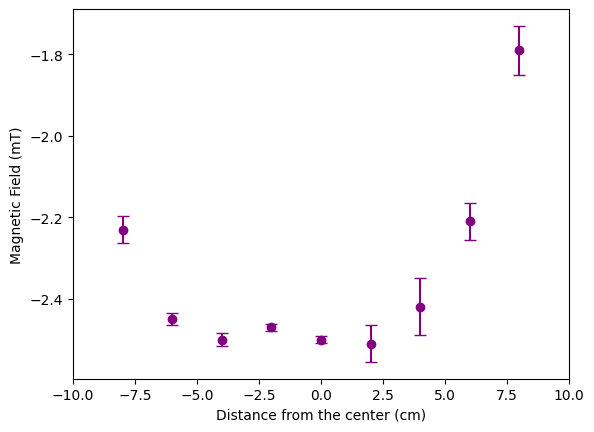

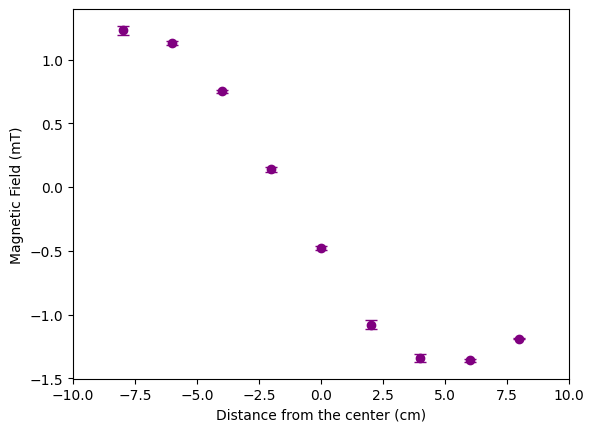

In [66]:
#Experiment 3 D & E

x = np.array([-8, -6, -4, -2, 0, 2, 4, 6, 8])


data_p = [-2.23, -2.45, -2.5, -2.47, -2.5, -2.51, -2.42, -2.21, -1.79]
stdev_p = [0.033, 0.014, 0.016, 0.009, 0.008, 0.045, 0.070, 0.045, 0.060]
data_ap = [1.23, 1.13, 0.75, 0.14, -0.48, -1.08, -1.34, -1.36, -1.19]
stdev_ap = [0.034, 0.012, 0.012, 0.019, 0.017, 0.037, 0.029, 0.012, 0.004]


fig, ax = plt.subplots()

ax.errorbar(x, data_p, yerr=stdev_p,
            fmt="o", color="purple", capsize=4,
           )
ax.set_xlim(-10, 10)
ax.set_xlabel("Distance from the center (cm)")
ax.set_ylabel("Magnetic Field (mT)")

plt.show()

fig, ax = plt.subplots()

ax.errorbar(x, data_ap, yerr=stdev_ap,
            fmt="o", color="purple", capsize=4,
           )
ax.set_xlim(-10, 10)
ax.set_xlabel("Distance from the center (cm)")
ax.set_ylabel("Magnetic Field (mT)")

plt.show()